In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Libraries

In [2]:
import os
from glob import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

2026-02-27 09:08:43.919250: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772183324.139748      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772183324.204758      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772183324.720851      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772183324.720893      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772183324.720896      23 computation_placer.cc:177] computation placer alr

Configuration

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
FINE_TUNE_EPOCHS = 5
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

Dataset Directory

In [4]:

DATASET_DIR = "/kaggle/input/vehicles-image-dataset/vehicle_data"

Collecting Image Paths and Labels

In [5]:
image_paths = []
labels = []

class_names = sorted(os.listdir(DATASET_DIR))
class_to_index = {name: idx for idx, name in enumerate(class_names)}

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

for class_name in class_names:
    class_dir = os.path.join(DATASET_DIR, class_name)
    for file in os.listdir(class_dir):
        if file.lower().endswith(VALID_EXTENSIONS):
            image_paths.append(os.path.join(class_dir, file))
            labels.append(class_to_index[class_name])

print("Total Images:", len(image_paths))
print("Total Classes:", len(class_names))

Total Images: 3680
Total Classes: 20


Train Test Validation Split

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.15,
    random_state=SEED,
    stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.176,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 2577
Validation: 551
Test: 552


In [7]:
from tensorflow.keras.applications.resnet50 import preprocess_input

Image Loader

In [8]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)   # Important for ResNet
    return img, label

Dataset Maker Function

In [9]:
def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.ignore_errors()   # safely skip bad images

    if training:
        ds = ds.shuffle(1000)
        ds = ds.repeat()

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

Creating Dataset

In [10]:
train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val, y_val)
test_ds  = make_dataset(X_test, y_test)

steps_per_epoch = len(X_train) // BATCH_SIZE
val_steps = len(X_val) // BATCH_SIZE

I0000 00:00:1772183354.527939      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772183354.533869      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


ResNet50 Base Model

In [11]:
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Custom Classification Head

In [12]:
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

Model Compilation

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,117,396 (92.00 MB)

 Trainable params: 529,684 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Training Model

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps
)

Epoch 1/10


Corrupt JPEG data: 5 extraneous bytes before marker 0xd9
I0000 00:00:1772183382.008335      65 service.cc:152] XLA service 0x78724c14fe80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772183382.008376      65 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772183382.008381      65 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772183383.945841      65 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/80 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.0234 - loss: 3.6933  

I0000 00:00:1772183389.013791      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


48/80 ━━━━━━━━━━━━━━━━━━━━ 18s 589ms/step - accuracy: 0.0967 - loss: 3.3460

...

80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 554ms/step - accuracy: 0.8674 - loss: 0.4658 - val_accuracy: 0.8361 - val_loss: 0.4970
Epoch 9/10
48/80 ━━━━━━━━━━━━━━━━━━━━ 12s 385ms/step - accuracy: 0.8774 - loss: 0.4315

Corrupt JPEG data: 5 extraneous bytes before marker 0xd9


80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 544ms/step - accuracy: 0.8752 - loss: 0.4320 - val_accuracy: 0.8340 - val_loss: 0.4763
Epoch 10/10
39/80 ━━━━━━━━━━━━━━━━━━━━ 15s 367ms/step - accuracy: 0.8866 - loss: 0.3755

Corrupt JPEG data: 5 extraneous bytes before marker 0xd9


80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 559ms/step - accuracy: 0.8839 - loss: 0.3891 - val_accuracy: 0.8299 - val_loss: 0.4708


Getting Prediction For Test Dataset

In [16]:
y_true = []
y_pred = []

for images, batch_labels in test_ds:
    preds = model.predict(images)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

test_accuracy = accuracy_score(y_true, y_pred)
print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Test Accuracy: 0.8528225806451613


Classification Report 

In [17]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.90      0.86      0.88        21
   ambulance       0.88      0.81      0.85        27
     bicycle       0.90      0.83      0.86        23
        boat       0.63      0.85      0.72        26
         bus       0.96      0.89      0.92        27
         car       0.88      0.88      0.88        25
  fire_truck       0.87      0.93      0.90        28
  helicopter       0.93      0.96      0.95        27
  hovercraft       0.95      0.81      0.88        26
     jet_ski       0.88      0.84      0.86        25
       kayak       0.67      0.67      0.67        24
  motorcycle       0.68      0.92      0.78        25
    rickshaw       0.90      0.86      0.88        22
     scooter       0.91      0.80      0.85        25
      segway       0.82      0.74      0.78        19
  skateboard       0.92      0.88      0.90        25
     tractor       0.96      0.89      0.93        28
       truck       0.87    

Plotting Confusion Matrix

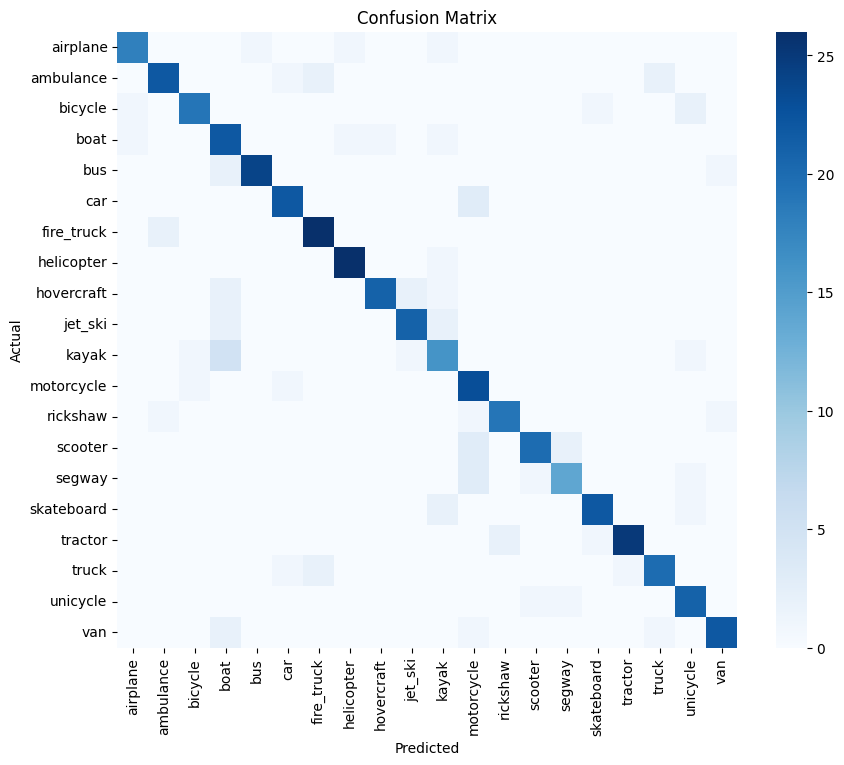

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Finetuning Base Model  

In [19]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps
)

Epoch 1/5


Corrupt JPEG data: 5 extraneous bytes before marker 0xd9


47/80 ━━━━━━━━━━━━━━━━━━━━ 17s 539ms/step - accuracy: 0.8755 - loss: 0.4142

Corrupt JPEG data: 5 extraneous bytes before marker 0xd9


80/80 ━━━━━━━━━━━━━━━━━━━━ 85s 678ms/step - accuracy: 0.8786 - loss: 0.4211 - val_accuracy: 0.8402 - val_loss: 0.4638
Epoch 2/5
 1/80 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.7188 - loss: 0.5722

...

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.9296 - loss: 0.2665

Corrupt JPEG data: 5 extraneous bytes before marker 0xd9


80/80 ━━━━━━━━━━━━━━━━━━━━ 48s 608ms/step - accuracy: 0.9296 - loss: 0.2664 - val_accuracy: 0.8566 - val_loss: 0.4403
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9484 - loss: 0.2324

Corrupt JPEG data: 5 extraneous bytes before marker 0xd9


80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 551ms/step - accuracy: 0.9484 - loss: 0.2323 - val_accuracy: 0.8566 - val_loss: 0.4340


Getting prediction from finetuned model

In [20]:
y_true = []
y_pred = []

for images, batch_labels in test_ds:
    preds = model.predict(images)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

test_accuracy = accuracy_score(y_true, y_pred)
print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Test Accuracy: 0.8830645161290323


Classification Report 

In [21]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.90      0.90      0.90        21
   ambulance       0.92      0.81      0.86        27
     bicycle       0.83      0.87      0.85        23
        boat       0.71      0.85      0.77        26
         bus       0.96      0.93      0.94        27
         car       0.92      0.96      0.94        25
  fire_truck       0.87      0.93      0.90        28
  helicopter       0.96      0.96      0.96        27
  hovercraft       0.96      0.88      0.92        26
     jet_ski       0.81      0.88      0.85        25
       kayak       0.75      0.62      0.68        24
  motorcycle       0.77      0.96      0.86        25
    rickshaw       0.91      0.91      0.91        22
     scooter       0.95      0.80      0.87        25
      segway       0.88      0.79      0.83        19
  skateboard       0.86      0.96      0.91        25
     tractor       0.96      0.89      0.93        28
       truck       0.87    

Confusion Matrix

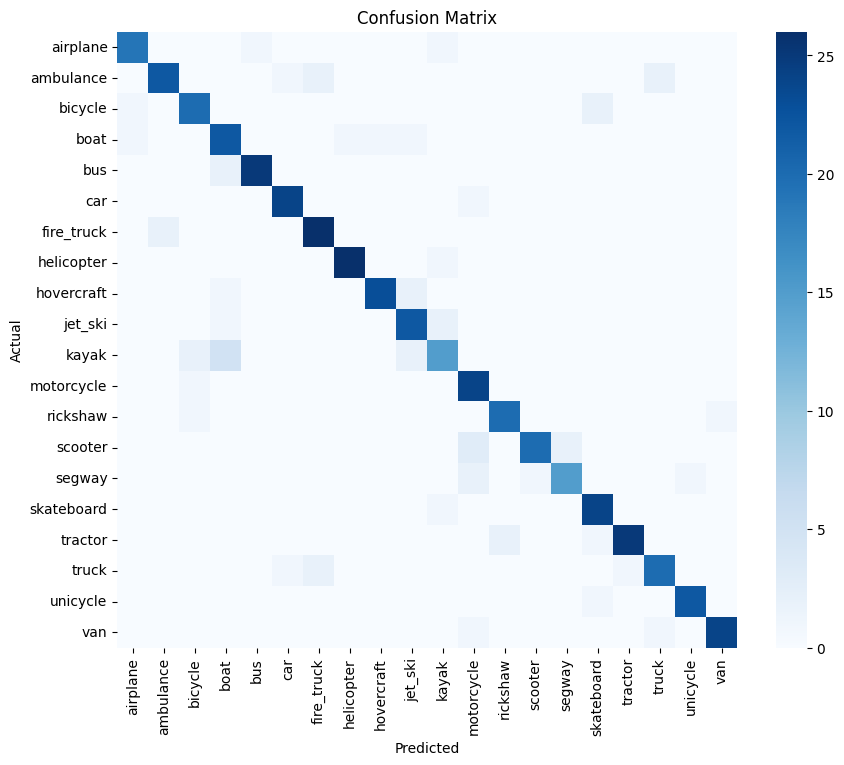

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()